In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


## Sistema de dos cuerpos

In [2]:
G = 1

sistema = [
    dict(m = 1 , r = np.array([0,0,0]), v = np.array([0,0,0])),
    dict( m = 0.01, r = np.array([1,0,0]), v = np.array([0,np.sqrt(2 * G * 1/1),0]))
]

## Energía total $ E = K + U$

In [3]:
K = 0.5 * sistema[1]['m'] * np.linalg.norm(sistema[1]['v'])**2 + \
    0.5 * sistema[0]['m'] * np.linalg.norm(sistema[0]['v'])**2

K

np.float64(0.010000000000000002)

In [4]:
G = 1

U = -G * sistema[0]['m'] * sistema[1]['m'] / np.linalg.norm(sistema[1]['r'] - sistema[0]['r'])

U

np.float64(-0.01)

In [5]:
E = K + U   #Como da negativa, el sistema no se va a desligar

E

np.float64(1.734723475976807e-18)

## Probando con un experimento

In [6]:
ts = np.linspace(0, 10, 100)

rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

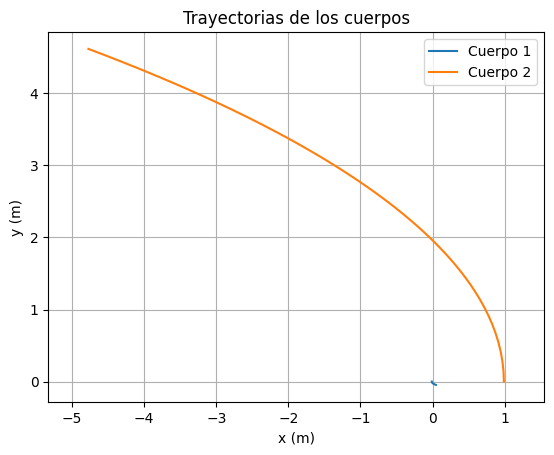

In [7]:
# Vamos a graficar las trayectorias desde el centro de masa

plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.grid(True)
plt.axis('equal') #Iguala las escalas de los ejes para que las trayectorias se vean proporcionadas
plt.show()

In [8]:
import plotly.graph_objects as go

fig = go.Figure()

# Trayectoria Cuerpo 1
fig.add_trace(go.Scatter3d(
    x=rps[0,:,0], y=rps[0,:,1], z=rps[0,:,2],
    mode='lines',
    name='Cuerpo 1'
))

# Trayectoria Cuerpo 2
fig.add_trace(go.Scatter3d(
    x=rps[1,:,0], y=rps[1,:,1], z=rps[1,:,2],
    mode='lines',
    name='Cuerpo 2'
))

fig.update_layout(
    title='Trayectorias de los cuerpos en 3D',
    scene=dict(
        xaxis_title='x (m)',
        yaxis_title='y (m)',
        zaxis_title='z (m)',
        aspectmode='data' # Iguala las escalas de los ejes
    )
)

fig.show()

## La masa de los cuerpos sí importan para trazar sus órbitas

## Simulación con Rebound

In [9]:
!pip install rebound


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\mecanicacelev\Scripts\python.exe -m pip install --upgrade pip


In [10]:
import rebound as rb

In [13]:
#Definir los cuerpos
sim = rb.Simulation()
sim.add(m = 1)
sim.add(m = 0.01, x = 1, vy = 0.01)

In [14]:
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))
rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    rs[0, i] = sim.particles[0].xyz
    vs[0, i] = sim.particles[0].vxyz
    rs[1, i] = sim.particles[1].xyz
    vs[1, i] = sim.particles[1].vxyz

    sim.move_to_com()  # Mover al centro de masa  

    rps[0, i] = sim.particles[0].xyz
    vps[0, i] = sim.particles[0].vxyz
    rps[1, i] = sim.particles[1].xyz
    vps[1, i] = sim.particles[1].vxyz

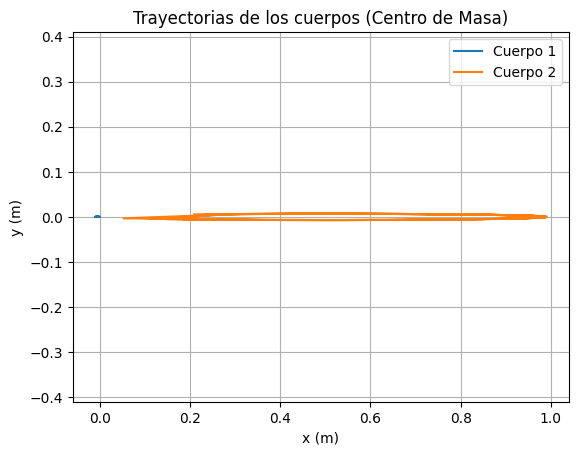

In [ ]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1') #Es con la velocidad de escape
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trayectorias de los cuerpos (Centro de Masa)')
plt.legend()
plt.axis('equal')
plt.grid(True)

In [19]:
sim_solar = rb.Simulation()
sim_solar.add('Sun', date = '2029-01-01')
sim_solar.add('Earth', date = '2029-01-01')  # Tierra
sim_solar.add('Apophis', date = '2029-01-01')  # Apophis

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


c:\Users\ASUS\Downloads\Mecanica_cel\Mec-nica_Celeste-main\Mec-nica_Celeste\mecanicacelev\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)
